# Joint Fisher Forecast: PFS + DESI-DR2 BAO + CMB ($\nu\Lambda$CDM)

Combined Fisher forecast from three independent probes:
- **PFS full-shape** $P_\ell(k) + B_0$ (7 redshift bins, $\ell = 0, 2, 4$, with AP effect)
- **DESI DR2 BAO** (13 data points across 7 redshift bins)
- **CMB** (Planck TTTEEE + low-$\ell$ TT + low-$\ell$ EE + Planck lensing + ACT DR6 lensing)

Neutrino mass $\Sigma m_\nu$ is **varied** around the fiducial $m_\nu = 0.06\,$eV.

**Shared cosmology basis**: $(\omega_b, \omega_c, \log A, n_s, h, \tau, m_\nu)$ — 7 parameters.

Prior convention: external BBN + weak $n_s$ (`ns10`) priors are applied only to non-CMB PFS/PFS+BAO reference cases. They are not included in CMB, BAO+CMB, or PFS+BAO+CMB combinations.

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-jaxptpolypol')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22,
})
import matplotlib.lines as mlines

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.linalg import inv

import candl_data
from ps_1loop_jax import background as bg

from jaxptpolypol.model import BispectrumTreeModel, CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_joint_params,
    pack_pk_params,
    unpack_joint_params,
    unpack_pk_params,
)
from jaxptpolypol.inference import (
    fisher_matrix,
    marginalize_fisher,
    marginalized_fisher_block,
    sigma_from_fisher,
    fixed_and_varied_indices,
    gaussian_prior_fisher,
    build_prior_sigmas,
    project_fisher_to_derived,
    fisher_diagnostics,
    format_fisher_diagnostics,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.theory import (
    build_bispectrum_triangles_from_k_grid,
    compute_fiducial_distances,
    make_gaussian_joint_covariance_fn,
    make_joint_pk_bk_fn,
)
from jaxptpolypol.priors import build_prior_sigmas_from_spec, load_prior_spec
from jaxptpolypol.bao import load_desi_dr2, bao_fisher_matrix, add_bao_to_fullshape_fisher
from jaxptpolypol.cmb import (
    CandlParameterLayout,
    get_candl_default_parameters,
    get_candl_parameter_names,
    load_candl_likelihood,
    make_candl_loglike_fn,
    make_candl_pars_to_theory_specs_fn,
    make_joint_loglike_fn,
)
from jaxptpolypol.marginalization import make_lcdm_corner_specs, project_case_to_specs


## Configuration

In [2]:
# ── Unified fiducial cosmology (Planck 2018 TT,TE,EE+lowE+lensing+BAO) ──
FIDUCIAL = {
    'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047,
    'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561, 'mnu': 0.06,
}

# ── PFS survey config ──
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
n_bar    = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)
n_zbins  = len(z_bins)

# ── Bispectrum / joint P+B config (matches fisher_multibin_*_AP_PB.ipynb) ──
K_PK_MIN, K_PK_MAX, N_K = 0.02, 0.20, 37
K_BK_MIN, K_BK_MAX = 0.02, 0.08
K_NL_RSD = 0.45
NUM_MU = NUM_PHI = 65
N_GL = 16
BB_POWER_MODEL = 'kaiser'   # C_BB from Kaiser P_ell; set '1loop' to reuse the 1-loop P_ell
BACKGROUND_MODE = 'direct'


# ── PFS emulator (mnu variant) ──
PFS_EMULATOR = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Pk_lin.npz'

# ── BAO data ──
BAO_DATA_DIR = "../../ext_data/bao_data/desi_bao_dr2"

# ── CMB config (mnu emulators) ──
PLANCK_ROOT = Path('/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0')
PLANCK_HIGHL   = PLANCK_ROOT / 'hi_l/plik/plik_rd12_HM_v22b_TTTEEE.clik'
PLANCK_LOWL_TT = PLANCK_ROOT / 'low_l/commander/commander_dx12_v3_2_29.clik'
PLANCK_LOWL_EE = PLANCK_ROOT / 'low_l/simall/simall_100x143_offlike5_EE_Aplanck_B.clik'
PLANCK_LENSING = PLANCK_ROOT / 'lensing/smicadx12_Dec5_ftl_mv2_ndclpp_p_teb_consext8_CMBmarged.clik_lensing'
ACT_DR6_LENS   = candl_data.ACT_DR6_Lens_only

CMB_EMULATOR_DIR = Path('/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks')
CMB_EMULATOR_FILENAMES = {
    'TT': str(CMB_EMULATOR_DIR / 'jense_2023_camb_mnu_Cl_tt.npz'),
    'TE': str(CMB_EMULATOR_DIR / 'jense_2023_camb_mnu_Cl_te.npz'),
    'EE': str(CMB_EMULATOR_DIR / 'jense_2023_camb_mnu_Cl_ee.npz'),
    'pp': str(CMB_EMULATOR_DIR / 'jense_2023_camb_mnu_Cl_pp.npz'),
}

COSMO_KEYS_CMB = ('H0', 'ombh2', 'omch2', 'logA', 'ns', 'tau', 'mnu')
FIDUCIAL_COSMO_CMB = {
    'H0': FIDUCIAL['h'] * 100,
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA': FIDUCIAL['logA'], 'ns': FIDUCIAL['ns'],
    'tau': FIDUCIAL['tau'], 'mnu': FIDUCIAL['mnu'],
}
INCLUDE_INTERNAL_PRIORS = True

# ── Shared basis (7 parameters for nuLCDM) ──
SHARED_KEYS = ('ombh2', 'omch2', 'logA', 'ns', 'h', 'tau', 'mnu')
N_SHARED = len(SHARED_KEYS)
SHARED_LABELS = (r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$', r'$\tau$', r'$m_\nu$')
FIDUCIAL_SHARED = np.array([FIDUCIAL[k] for k in SHARED_KEYS])

# ── External priors: applied only to non-CMB PFS/PFS+BAO reference cases. ──
COSMO_PRIORS_BBN_NS10 = {'ombh2': 0.00055, 'ns': 0.0422}
# Do not add these priors to CMB, BAO+CMB, or PFS+BAO+CMB combinations.
print("Unified fiducial:", FIDUCIAL)
print("CMB fiducial:", FIDUCIAL_COSMO_CMB)
print("Shared basis:", SHARED_KEYS)
print("Non-CMB priors: BBN sigma(ombh2)=0.00055, ns10 sigma(ns)=0.0422")
print("CMB-containing combinations do not include external BBN/ns10 priors")
MODEL_TITLE = r'$\nu\Lambda$CDM'

Unified fiducial: {'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047, 'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561, 'mnu': 0.06}
CMB fiducial: {'H0': 67.66, 'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047, 'ns': 0.9665, 'tau': 0.0561, 'mnu': 0.06}
Shared basis: ('ombh2', 'omch2', 'logA', 'ns', 'h', 'tau', 'mnu')
Non-CMB priors: BBN sigma(ombh2)=0.00055, ns10 sigma(ns)=0.0422
CMB-containing combinations do not include external BBN/ns10 priors


## Low-$\ell$ EE (simall) note

`planck_lowl_ee`/simall is now differentiable in clipy (cubic-spline likelihood), so each CMB Hessian Fisher carries the real low-$\ell$ EE information on `tau` directly. **No Gaussian `tau` prior is added** — the lowE optical-depth constraint comes from the likelihood's own curvature.


## Part 1 — PFS Full-Shape Fisher

In [3]:
# ── Emulator and model (mnu variant) ──
pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=PFS_EMULATOR)
ps1loop_model = PS1LoopModel(do_irres=True)
bispectrum_model = BispectrumTreeModel(do_AP=True, k_nl_rsd=K_NL_RSD)

# ── Fiducial cosmology (PFS basis) ──
cosmo_dict = {
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA':  FIDUCIAL['logA'],  'ns':    FIDUCIAL['ns'],
    'h':     FIDUCIAL['h'],
    'z':     0.7,       # placeholder; overridden per bin
    'A_b':   3.13, 'eta_b': 0.603, 'logT_AGN': 7.8,
    'mnu':   FIDUCIAL['mnu'],   # keep LAST: fixed_cosmo=[5,6,7,8] indexes z/A_b/eta_b/logT_AGN
}
cosmo = CosmoParams(cosmo_dict)

# ── Bias fitting functions (arXiv:1907.06666) ──
def b1z(z): return 0.9 + 0.4 * z
def b2z(z): return -0.704 - 0.208 * z + 0.183 * z**2 - 0.00771 * z**3
def bG2z(z): return -(2. / 7.) * (b1z(z) - 1.)
def bGamma3z(z): return (23. / 42.) * (b1z(z) - 1.)

def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=cosmo_dict['mnu'],
    ))

def c0z(z): return 25. * Dplusz(z)**2
def c2z(z): return 25. * Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

# ── Survey parameters per bin (P + B blocks) ──
surveys = []
for i, (z, knl, nd) in enumerate(zip(z_bins, knl_bins, n_bar)):
    s = FullShapeSurveyParams(
        shared={
            'bias': {'b1': b1z(z), 'b2': b2z(z), 'bG2': bG2z(z), 'bGamma3': bGamma3z(z)},
            'stoch': {'P_shot': 1.0},
            'k_nl': knl, 'ndens': nd,
        },
        pk={
            'ctr': {'c0': c0z(z), 'c2': c2z(z), 'c4': c4z(z), 'cfog': knl**(-4)},
            'stoch': {'a0': 0., 'a2': 0.},
        },
        bk={
            'ctr': {'c1': 0.0},
            'stoch': {'B_shot': 1.0, 'A_shot': 1.0},
        },
    )
    surveys.append(s)

joint_survey_keys = surveys[0].joint_param_keys

# ── Pack parameters (cosmo + joint P+B survey blocks) ──
packed_params = pack_joint_params(cosmo, surveys)
n_cosmo_params = sum(cosmo.param_sizes)
n_survey_params = len(joint_survey_keys)
print(f"Total parameters: {packed_params.shape[0]} ({n_cosmo_params} cosmo + {n_survey_params}×{n_zbins} survey)")

# ── Fiducial distances ──
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins, mnu=cosmo_dict['mnu'])
for z, Hz_val, DAz_val in zip(z_bins, Hz_fid, DAz_fid):
    print(f"  z={z}: H(z)={Hz_val:.2f} km/s/Mpc, D_A(z)={DAz_val:.2f} Mpc")


Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Total parameters: 122 (10 cosmo + 16×7 survey)
  z=0.7: H(z)=100.75 km/s/Mpc, D_A(z)=1517.28 Mpc
  z=0.9: H(z)=113.67 km/s/Mpc, D_A(z)=1652.58 Mpc
  z=1.1: H(z)=127.83 km/s/Mpc, D_A(z)=1732.11 Mpc
  z=1.3: H(z)=143.10 km/s/Mpc, D_A(z)=1774.25 Mpc
  z=1.5: H(z)=159.38 km/s/Mpc, D_A(z)=1791.13 Mpc
  z=1.8: H(z)=185.51 km/s/Mpc, D_A(z)=1786.02 Mpc
  z=2.2: H(z)=223.19 km/s/Mpc, D_A(z)=1746.9

In [4]:
# ── Differentiable joint P+B wrapper ──
joint_fn = make_joint_pk_bk_fn(
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    bispectrum_model=bispectrum_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=N_GL,
    num_mu=NUM_MU,
    num_phi=NUM_PHI,
    background_mode=BACKGROUND_MODE,
)
joint_cov_fn = make_gaussian_joint_covariance_fn(
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    bb_power_model=BB_POWER_MODEL,
    n_gl=N_GL,
    background_mode=BACKGROUND_MODE,
)
jitted_joint_fn = jax.jit(joint_fn)

# ── k grid and bispectrum triangles (same dk; canonical triangles inside (K_BK_MIN, K_BK_MAX)) ──
k = jnp.linspace(K_PK_MIN, K_PK_MAX, N_K)
dk = float(k[1] - k[0])
n_k = int(k.shape[0])
triangles, triangle_dk = build_bispectrum_triangles_from_k_grid(
    k, k_min=K_BK_MIN, k_max=K_BK_MAX, dk=dk,
)
n_tri = int(triangles.shape[0])
print(f"P grid: n_k={n_k}, dk={dk:.5f}; B triangles in ({K_BK_MIN}, {K_BK_MAX}): {n_tri}")

# ── Jacobian of the joint data vector ──
jitted_joint_fn(packed_params, k=k, triangles=triangles).block_until_ready()  # JIT warmup
%time jac = jax.jacfwd(jitted_joint_fn, argnums=0)(packed_params, k=k, triangles=triangles)
print(f"Per-bin joint block: 3*{n_k} + {n_tri}; Jacobian shape: {jac.shape}")

# ── Joint Gaussian covariance (C_PP + C_BB; C_PB currently zero in the library) ──
gauss_cov = joint_cov_fn(
    packed_params,
    V_survey=V_bins,
    k=k,
    dk=dk,
    triangles=triangles,
    triangle_dk=triangle_dk,
)

# ── PFS P+B Fisher matrix ──
F_pfs_full = fisher_matrix(gauss_cov, jac)
print(f"PFS P+B Fisher shape: {F_pfs_full.shape}")

# ── EFT/stochastic survey priors: DESI DR1-reanalysis spec (arXiv:2511.20757 Table I) ──
# Migrated from the legacy Eq.(12) spec (eft_eq12_2405_02252). Fisher priors are the
# FIDUCIAL (R=1) DESI widths; the c0/c2/c4 counterterm trio carries the MARGINAL widths
# of the correlated prior (off-diagonal correlations live only in the MCMC-side Sigma_p).
# DESI carries bGamma3 width 1.0 natively; b2/bG2 ~ 5/sigma8(z)^2; b1 flat (no prior).
# See docs/design/desi-convention-map.md.
from jaxptpolypol.inference import build_prior_sigmas
from jaxptpolypol.desi_priors import (
    load_desi_prior_spec, make_lcdm_rescaling_fns, build_prior_sigmas_from_desi_spec,
)
desi_spec = load_desi_prior_spec()  # desi_dr1_reanalysis_2511_20757
assert desi_spec.marginalized[('shared', 'bias', 'bGamma3')].sigma == 1.0
_s8_keys = ('ombh2', 'omch2', 'logA', 'ns', 'h', 'mnu')
_, _, sigma8_ref_bins = make_lcdm_rescaling_fns(
    pklin_emulator=pklin_emulator,
    cosmo_keys=_s8_keys, cosmo_sizes=(1,) * len(_s8_keys),
    z_bins=z_bins,
    fid_cosmo_native=jnp.array([cosmo_dict[k] for k in _s8_keys]),
    mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
    fixed_cosmo_extras={'A_b': cosmo_dict['A_b'], 'eta_b': cosmo_dict['eta_b'],
                        'logT_AGN': cosmo_dict['logT_AGN']},
)
_survey_sigma_dicts, _sampled_sigma_bins = build_prior_sigmas_from_desi_spec(
    desi_spec, knl_bins=knl_bins, sigma8_ref_bins=sigma8_ref_bins,
)
desi_survey_priors = []
for _b in range(n_zbins):
    _d = dict(_survey_sigma_dicts[_b])
    _d[('shared', 'bias', 'b2')] = _sampled_sigma_bins[_b]['b2']
    _d[('shared', 'bias', 'bG2')] = _sampled_sigma_bins[_b]['bG2']
    desi_survey_priors.append(_d)
prior_sigmas = build_prior_sigmas(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    n_bins=n_zbins,
    cosmo_priors=None,
    survey_priors=desi_survey_priors,
)
F_pfs_full = F_pfs_full + gaussian_prior_fisher(packed_params.shape[0], prior_sigmas)
print("Applied DESI DR1-reanalysis EFT/stochastic survey priors (arXiv:2511.20757 Table I; no cosmo priors)")


P grid: n_k=37, dk=0.00500; B triangles in (0.02, 0.08): 264
CPU times: user 17min 30s, sys: 7min 56s, total: 25min 26s
Wall time: 5min 37s
Per-bin joint block: 3*37 + 264; Jacobian shape: (2625, 122)
PFS P+B Fisher shape: (122, 122)
Applied Eq. (12) EFT/stochastic survey priors from arXiv:2405.02252 (no cosmo priors)


## Part 2 — DESI DR2 BAO Fisher

In [5]:
bao_dr2 = load_desi_dr2("all", data_dir=BAO_DATA_DIR)
fiducial_cosmo = packed_params[:n_cosmo_params]

F_bao = bao_fisher_matrix(
    bao_dr2, fiducial_cosmo,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,
    mnu_fixed=cosmo_dict['mnu'],
)
F_pfs_bao_full = add_bao_to_fullshape_fisher(F_pfs_full, F_bao, n_cosmo=n_cosmo_params)

print(f"DESI DR2 BAO data points: {len(bao_dr2.data_points)}")
print(f"BAO Fisher shape: {F_bao.shape}")

DESI DR2 BAO data points: 13
BAO Fisher shape: (10, 10)


## Part 3 — PFS marginalisation and non-CMB external priors

In [6]:
# ── Remove truly fixed parameters ──
fixed_cosmo = [5, 6, 7, 8]  # z, A_b, eta_b, logT_AGN
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(joint_survey_keys) if key in fixed_survey_keys]

fixed_idx, varied_idx = fixed_and_varied_indices(
    n_cosmo_params, n_survey_params, n_zbins, fixed_cosmo, fixed_survey_offsets,
)
print(f"Fixed: {len(fixed_idx)}, Varied: {len(varied_idx)}")

cosmo_varied_global = [i for i in range(n_cosmo_params) if i not in fixed_cosmo]
cosmo_varied_marg = [list(varied_idx).index(i) for i in cosmo_varied_global]
n_pfs_cosmo = len(cosmo_varied_marg)
print(f"PFS varied cosmo params: {n_pfs_cosmo}, indices in marg vector: {cosmo_varied_marg}")

prior_sigmas_bbn_ns10 = build_prior_sigmas(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=joint_survey_keys,
    n_bins=n_zbins,
    cosmo_priors=COSMO_PRIORS_BBN_NS10,
)
F_prior_bbn_ns10 = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas_bbn_ns10)
F_pfs_prior_full = F_pfs_full + F_prior_bbn_ns10
F_pfs_bao_prior_full = F_pfs_bao_full + F_prior_bbn_ns10

F_pfs_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_full, varied_idx), cosmo_varied_marg,
)
F_pfs_bao_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_full, varied_idx), cosmo_varied_marg,
)
F_pfs_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_prior_full, varied_idx), cosmo_varied_marg,
)
F_pfs_bao_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_prior_full, varied_idx), cosmo_varied_marg,
)
print(f"PFS cosmo-only Fisher shape: {F_pfs_cosmo.shape}")
print('Applied BBN+ns10 priors only to non-CMB PFS and PFS+BAO reference cases')

Fixed: 18, Varied: 104
PFS varied cosmo params: 6, indices in marg vector: [0, 1, 2, 3, 4, 5]
PFS cosmo-only Fisher shape: (6, 6)
Applied BBN+ns10 priors only to non-CMB PFS and PFS+BAO reference cases


## Part 4 — CMB Fisher (Planck + ACT DR6 lensing)

In [7]:
def scalar_value(value):
    return float(np.asarray(value).reshape(()))


def ordered_union(name_lists):
    ordered, seen = [], set()
    for names in name_lists:
        for name in names:
            if name not in seen:
                seen.add(name)
                ordered.append(name)
    return tuple(ordered)


def load_likelihood_terms():
    clipy_args = {'all_priors': True} if INCLUDE_INTERNAL_PRIORS else {}
    return {
        'planck_highl': load_candl_likelihood(str(PLANCK_HIGHL), wrapper='clipy', additional_args=clipy_args),
        'planck_lowl_tt': load_candl_likelihood(str(PLANCK_LOWL_TT), wrapper='clipy', additional_args=clipy_args),
        'planck_lowl_ee': load_candl_likelihood(str(PLANCK_LOWL_EE), wrapper='clipy', additional_args=clipy_args),
        'planck_lensing': load_candl_likelihood(str(PLANCK_LENSING), wrapper='clipy', additional_args=clipy_args),
        'act_dr6_lensing': load_candl_likelihood(
            ACT_DR6_LENS, lensing=True, feedback=False,
            clear_internal_priors=not INCLUDE_INTERNAL_PRIORS,
        ),
    }


def collect_cmb_nuisance_defaults(likelihoods):
    nuisance_names_by_term, nuisance_defaults = {}, {}
    for term_name, like in likelihoods.items():
        names = get_candl_parameter_names(like, cosmo_keys=COSMO_KEYS_CMB, include_prior_params=True)
        nuisance_names_by_term[term_name] = names
        for key, value in get_candl_default_parameters(like).items():
            nuisance_defaults.setdefault(key, scalar_value(value))
    nuisance_names = ordered_union(nuisance_names_by_term.values())
    missing_defaults = [name for name in nuisance_names if name not in nuisance_defaults]
    if missing_defaults:
        raise ValueError(
            'Missing default values for CMB nuisance parameters: '
            + ', '.join(missing_defaults)
        )
    return nuisance_names, nuisance_defaults, nuisance_names_by_term


In [8]:
# ── Load likelihoods and emulators ──
pars_to_theory_specs = make_candl_pars_to_theory_specs_fn(emulator_filenames=CMB_EMULATOR_FILENAMES)
likelihoods = load_likelihood_terms()
nuisance_names, nuisance_defaults, nuisance_names_by_term = collect_cmb_nuisance_defaults(likelihoods)

# ── Layout: cosmo + sampled nuisance ──
sampled_nuisance = tuple(nuisance_names)
layout = CandlParameterLayout(
    cosmo_keys=tuple(COSMO_KEYS_CMB),
    cosmo_sizes=tuple(1 for _ in COSMO_KEYS_CMB),
    cmb_nuisance_names=sampled_nuisance,
)
cmb_param_order = tuple(COSMO_KEYS_CMB) + tuple(sampled_nuisance)
theta_fid_cmb = layout.pack(
    CosmoParams(FIDUCIAL_COSMO_CMB),
    {name: nuisance_defaults[name] for name in sampled_nuisance},
)
fixed_cmb_params = {}

# ── Build per-term log-likelihoods ──
term_loglikes = {}
for term_name, like in likelihoods.items():
    term_loglikes[term_name] = make_candl_loglike_fn(
        like, pars_to_theory_specs=pars_to_theory_specs,
        layout=layout, fixed_cmb_params=fixed_cmb_params,
    )

# ── Joint CMB log-likelihood ──
all_term_names = list(term_loglikes.keys())
joint_cmb_loglike = make_joint_loglike_fn(
    extra_loglike_fns=[term_loglikes[name] for name in all_term_names],
)

print(f"CMB parameter vector length: {theta_fid_cmb.shape[0]}")
print(f"  Cosmo: {len(COSMO_KEYS_CMB)}, Nuisance: {len(sampled_nuisance)}")
print(f"CMB terms: {all_term_names}")

# ── Hessian-based Fisher ──
print("\nComputing CMB Hessian (this may take a few minutes)...")
hess_fn = jax.jit(jax.hessian(joint_cmb_loglike))
%time hess = np.asarray(hess_fn(theta_fid_cmb))  # first call includes JIT compile

F_cmb_full = -0.5 * (hess + hess.T)
print(f"CMB full Fisher shape: {F_cmb_full.shape}")

# ── Marginalise over CMB nuisance → cosmo-only ──
cmb_cosmo_idx = list(range(len(COSMO_KEYS_CMB)))
F_cmb_cosmo = marginalized_fisher_block(F_cmb_full, cmb_cosmo_idx)
print(f"CMB cosmo-only Fisher shape: {F_cmb_cosmo.shape}")
print(format_fisher_diagnostics(fisher_diagnostics(F_cmb_cosmo, param_names=list(COSMO_KEYS_CMB))))


Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you r

## Part 5 — Project to shared basis and combine

In [9]:
# ── Project CMB Fisher from (H0, ombh2, omch2, logA, ns, tau, mnu)
#    to shared basis (ombh2, omch2, logA, ns, h, tau, mnu) ──
def cmb_to_shared(params):
    H0     = params[COSMO_KEYS_CMB.index('H0')]
    ombh2  = params[COSMO_KEYS_CMB.index('ombh2')]
    omch2  = params[COSMO_KEYS_CMB.index('omch2')]
    logA   = params[COSMO_KEYS_CMB.index('logA')]
    ns     = params[COSMO_KEYS_CMB.index('ns')]
    tau    = params[COSMO_KEYS_CMB.index('tau')]
    mnu    = params[COSMO_KEYS_CMB.index('mnu')]
    return jnp.array([ombh2, omch2, logA, ns, H0 / 100.0, tau, mnu])

fid_cmb_cosmo = jnp.array([FIDUCIAL_COSMO_CMB[k] for k in COSMO_KEYS_CMB], dtype=jnp.float64)
F_cmb_shared, fid_cmb_derived, _, _ = project_fisher_to_derived(
    F_cmb_cosmo, fid_cmb_cosmo, cmb_to_shared,
)
print("CMB Fisher projected to shared basis.")
print(f"  Fiducial (shared): {fid_cmb_derived}")

# ── Embed PFS/BAO cosmology Fisher matrices into shared basis (7x7) ──
# PFS cosmo order: (ombh2, omch2, logA, ns, h, mnu) → shared indices [0,1,2,3,4,6]
# (tau at index 5 is unconstrained by PFS/BAO)
pfs_idx = [0, 1, 2, 3, 4, 6]

def embed_fisher(F_sub, indices, n_total):
    F = np.zeros((n_total, n_total))
    idx = np.array(indices)
    F[np.ix_(idx, idx)] = np.asarray(F_sub)
    return F

F_bao_cosmo = np.asarray(F_bao)[np.ix_(cosmo_varied_global, cosmo_varied_global)]
F_pfs_shared           = embed_fisher(F_pfs_cosmo,           pfs_idx, N_SHARED)
F_bao_shared           = embed_fisher(F_bao_cosmo,           pfs_idx, N_SHARED)
F_pfs_bao_shared       = embed_fisher(F_pfs_bao_cosmo,       pfs_idx, N_SHARED)
F_pfs_prior_shared     = embed_fisher(F_pfs_prior_cosmo,     pfs_idx, N_SHARED)
F_pfs_bao_prior_shared = embed_fisher(F_pfs_bao_prior_cosmo, pfs_idx, N_SHARED)

# ── Joint combinations; CMB-containing sums intentionally exclude BBN/ns10. ──
F_cmb_shared = np.asarray(F_cmb_shared)
F_bao_cmb_shared = F_bao_shared + F_cmb_shared
F_joint = F_pfs_bao_shared + F_cmb_shared

print("\nFisher matrices in shared basis (7x7):")
print(f"  PFS+BBN+ns10:      rank = {np.linalg.matrix_rank(F_pfs_prior_shared)}")
print(f"  BAO-only:      rank = {np.linalg.matrix_rank(F_bao_shared)}")
print(f"  PFS+BAO+BBN+ns10:  rank = {np.linalg.matrix_rank(F_pfs_bao_prior_shared)}")
print(f"  CMB-only:      rank = {np.linalg.matrix_rank(F_cmb_shared)}")
print(f"  BAO+CMB:       rank = {np.linalg.matrix_rank(F_bao_cmb_shared)}")
print(f"  PFS+BAO+CMB:        rank = {np.linalg.matrix_rank(F_joint)}")

CMB Fisher projected to shared basis.
  Fiducial (shared): [0.02242 0.11933 3.047   0.9665  0.6766  0.0561  0.06   ]

Fisher matrices in shared basis (7x7):
  PFS+BBN+ns10:      rank = 6
  BAO-only:      rank = 2
  PFS+BAO+BBN+ns10:  rank = 6
  CMB-only:      rank = 7
  BAO+CMB:       rank = 7
  PFS+BAO+CMB:        rank = 7


## Results

In [10]:
# ── Compute marginalized 1sigma from each shared-basis Fisher ──
def safe_sigma(F):
    try:
        cov = np.linalg.inv(0.5 * (F + F.T))
        d = np.diag(cov)
        return np.where(d > 0, np.sqrt(d), np.inf)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(0.5 * (F + F.T))
        d = np.diag(cov)
        return np.where(d > 0, np.sqrt(d), np.inf)

cases = {
    'PFS+BBN+ns10':          F_pfs_prior_shared,
    'PFS+BAO+BBN+ns10':      F_pfs_bao_prior_shared,
    'CMB':                   F_cmb_shared,
    'BAO+CMB':               F_bao_cmb_shared,
    'PFS P+B+BAO+CMB':           F_joint,
}
sigmas = {label: safe_sigma(F) for label, F in cases.items()}

header = f"{'Param':>8s}  {'Fiducial':>10s}"
for label in cases:
    header += f"  {label:>14s}"
print(header)
print("-" * len(header))
for i, key in enumerate(SHARED_KEYS):
    row = f"{key:>8s}  {FIDUCIAL_SHARED[i]:10.5g}"
    for label in cases:
        s = sigmas[label][i]
        row += f"  {s:14.5g}" if np.isfinite(s) else f"  {'---':>14s}"
    print(row)

   Param    Fiducial    PFS+BBN+ns10  PFS+BAO+BBN+ns10             CMB         BAO+CMB  PFS P+B+BAO+CMB
-------------------------------------------------------------------------------------------------------
   ombh2     0.02242      0.00054148      0.00048103      7.1097e-05      0.00012803      0.00012418
   omch2     0.11933       0.0044946       0.0034147             ---      0.00074321      0.00069344
    logA       3.047         0.16953         0.12668         0.01015        0.013702        0.013449
      ns      0.9665         0.03872        0.035103       0.0019755       0.0036383       0.0035997
       h      0.6766       0.0048389         0.00433             ---       0.0039234       0.0024608
     tau      0.0561             ---             ---       0.0062585       0.0071499       0.0070045
     mnu        0.06         0.31561         0.19821             ---        0.049602         0.03679


/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/3617040891.py:6: RuntimeWarning: invalid value encountered in sqrt
  return np.where(d > 0, np.sqrt(d), np.inf)


In [11]:
# Projected constraints on standard parameters
def projected_sigmas_from_fisher(fisher, rcond=1e-12):
    fisher = np.asarray(fisher, dtype=float)
    fisher = 0.5 * (fisher + fisher.T)
    eigvals = np.linalg.eigvalsh(fisher)
    scale = max(float(np.max(np.abs(eigvals))) if eigvals.size else 0.0, 1.0)
    if np.count_nonzero(eigvals > rcond * scale) < fisher.shape[0]:
        return np.full(fisher.shape[0], np.inf)
    cov = np.linalg.inv(fisher)
    diag = np.diag(cov)
    return np.where(diag > 0.0, np.sqrt(diag), np.inf)

native_cosmo_keys = tuple(SHARED_KEYS)
selected_plot_specs = list(
    make_lcdm_corner_specs(
        native_cosmo_keys,
        pklin_emulator=pklin_emulator,
        mnu_name='mnu',
        mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
        fixed_cosmo_values=cosmo_dict,
    )
) + ['mnu']

selected_fisher_cases = []
for label, fisher_case in cases.items():
    projection = project_case_to_specs(
        fisher_case,
        FIDUCIAL_SHARED,
        np.arange(N_SHARED),
        native_cosmo_keys,
        selected_plot_specs,
    )
    selected_fisher_cases.append({'label': label, 'projection': projection})

selected_param_names = selected_fisher_cases[0]['projection'].plot_names
selected_param_labels = selected_fisher_cases[0]['projection'].plot_labels

print('Marginalized 1-sigma constraints for selected projected parameters')
print('=' * 110)
header = f"{'Parameter':>18s}  {'Fiducial':>12s}"
for case in selected_fisher_cases:
    header += f"  {case['label']:>16s}"
print(header)
print('-' * len(header))

for i, name in enumerate(selected_param_labels):
    fid = float(selected_fisher_cases[0]['projection'].fid_plot[i])
    sigma_vals = [
        float(projected_sigmas_from_fisher(case['projection'].fisher_plot)[i])
        for case in selected_fisher_cases
    ]
    row = f"{name:>18s}  {fid:12.5g}"
    for sigma in sigma_vals:
        row += f"  {sigma:16.5g}" if np.isfinite(sigma) else f"  {'---':>16s}"
    print(row)


Marginalized 1-sigma constraints for selected projected parameters
         Parameter      Fiducial      PFS+BBN+ns10  PFS+BAO+BBN+ns10               CMB           BAO+CMB   PFS P+B+BAO+CMB
--------------------------------------------------------------------------------------------------------------------------
        $\Omega_m$       0.31105          0.014806         0.0076271               ---         0.0046508         0.0030294
             $H_0$         67.66           0.48389             0.433               ---           0.39234           0.24608
        $\sigma_8$       0.81034          0.021779          0.021159               ---          0.011418          0.008537
      $\sum m_\nu$          0.06           0.31561           0.19821               ---          0.049602           0.03679


## Summary: 1D marginal constraints on derived parameters

$\Omega_m$, $H_0$, $\sigma_8$ reported as marginalized 1$\sigma$; $\sum m_\nu$ (nuLCDM) reported as a 95% one-sided upper limit.

In [12]:
# ── Summary: 1D marginal constraints on (Omega_m, H0, sigma8[, sum m_nu]) ──
# Omega_m, H0, sigma8: marginalized 1-sigma.
# Sum m_nu (when varied): 95% CL upper limit (eV) from the Gaussian posterior
# truncated at m_nu >= 0 and renormalized, reported for two fiducial conventions:
#   (1) fiducial m_nu = 0.06 eV  (this forecast's fiducial)
#   (2) fiducial m_nu = 0        (non-detection convention; -> ~1.96 sigma)
# The raw 1-sigma sensitivity sigma(m_nu) is also listed.
from scipy.stats import norm

def _is_mnu(name, label):
    s = (str(name) + " " + str(label)).lower()
    return "mnu" in s or "m_nu" in s or r"m_\nu" in s or r"\nu" in s

def mnu_ul_truncated(mu, sigma, cl=0.95):
    """95% CL upper limit of N(mu, sigma) truncated to m_nu >= 0 and renormalized.

    M = mu + sigma * Phi^{-1}( cl + (1-cl) * Phi(-mu/sigma) ).
    Reduces to mu + 1.645 sigma for mu >> sigma, and to 1.96 sigma for mu = 0.
    """
    return float(mu + sigma * norm.ppf(cl + (1.0 - cl) * norm.cdf(-mu / sigma)))

summary_fid = selected_fisher_cases[0]['projection'].fid_plot
sig_of = lambda idx: [float(projected_sigmas_from_fisher(c['projection'].fisher_plot)[idx])
                      for c in selected_fisher_cases]
has_mnu = any(_is_mnu(n, l) for n, l in zip(selected_param_names, selected_param_labels))

header = f"{'Parameter':>18s}  {'Fiducial':>10s}"
for case in selected_fisher_cases:
    header += f"  {case['label']:>20s}"

print("=" * len(header))
print("Marginal constraints on derived parameters")
print("  Omega_m, H0, sigma8: marginalized 1-sigma.")
if has_mnu:
    print("  Sum m_nu: 95% CL upper limit (eV), Gaussian truncated at m_nu >= 0;")
    print("            fiducial m_nu = 0.06 eV, and fiducial m_nu = 0 (~1.96 sigma).")
print("=" * len(header))
print(header)
print("-" * len(header))
for i, (name, label) in enumerate(zip(selected_param_names, selected_param_labels)):
    fid = float(summary_fid[i])
    sig = sig_of(i)
    if _is_mnu(name, label):
        def _ul_row(rlabel, mu):
            r = f"{rlabel:>18s}  {mu:10.5g}"
            for s in sig:
                r += f"  {('---' if not np.isfinite(s) else '< %.4f' % mnu_ul_truncated(mu, s)):>20s}"
            print(r)
        r = f"{'sigma(m_nu)':>18s}  {'':>10s}"
        for s in sig:
            r += f"  {('---' if not np.isfinite(s) else '%.5g' % s):>20s}"
        print(r)
        _ul_row('m_nu UL (fid=0.06)', fid)
        _ul_row('m_nu UL (fid=0)', 0.0)
    else:
        r = f"{name:>18s}  {fid:10.5g}"
        for s in sig:
            r += f"  {('---' if not np.isfinite(s) else '%.5g' % s):>20s}"
        print(r)
print("-" * len(header))
if has_mnu:
    print("m_nu: sigma is 1-sigma; UL rows are 95% CL upper limits (eV), Gaussian truncated at 0.")
print("All non-m_nu entries are marginalized 1-sigma.")

Marginal constraints on derived parameters
  Omega_m, H0, sigma8: 1-sigma.   Sum m_nu: 95% one-sided upper limit (fiducial + 1.645 sigma), in eV.
   Parameter    Fiducial          PFS+BBN+ns10      PFS+BAO+BBN+ns10                   CMB               BAO+CMB       PFS P+B+BAO+CMB
--------------------------------------------------------------------------------------------------------------------------------------
     Omega_m     0.31105              0.014806             0.0076271                   ---             0.0046508             0.0030294
          H0       67.66               0.48389                 0.433                   ---               0.39234               0.24608
      sigma8     0.81034              0.021779              0.021159                   ---              0.011418              0.008537
         mnu        0.06              < 0.5792              < 0.3861                   ---              < 0.1416              < 0.1205
--------------------------------------------

## Projected corner plot

Marginalized constraints projected onto the standard parameters ($\Omega_m$, $H_0$, $\sigma_8$, plus $\sum m_\nu$ when varied), from the same `make_lcdm_corner_specs` projection as the table above.

/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/1164120832.py:40: RuntimeWarning: Skipping Gaussian marginal for index 0 because the variance is not finite and non-negative.
  plot_Gaussian(F, case['projection'].fid_plot, i, ax=ax,
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/1164120832.py:27: RuntimeWarning: Skipping contour for indices [0, 1] because the marginal covariance is not positive semidefinite.
  plot_contours(
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/1164120832.py:40: RuntimeWarning: Skipping Gaussian marginal for index 1 because the variance is not finite and non-negative.
  plot_Gaussian(F, case['projection'].fid_plot, i, ax=ax,
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/1164120832.py:27: RuntimeWarning: Skipping contour for indices [0, 2] because the marginal covariance is not positive semidefinite.
  plot_contours(
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/116412083

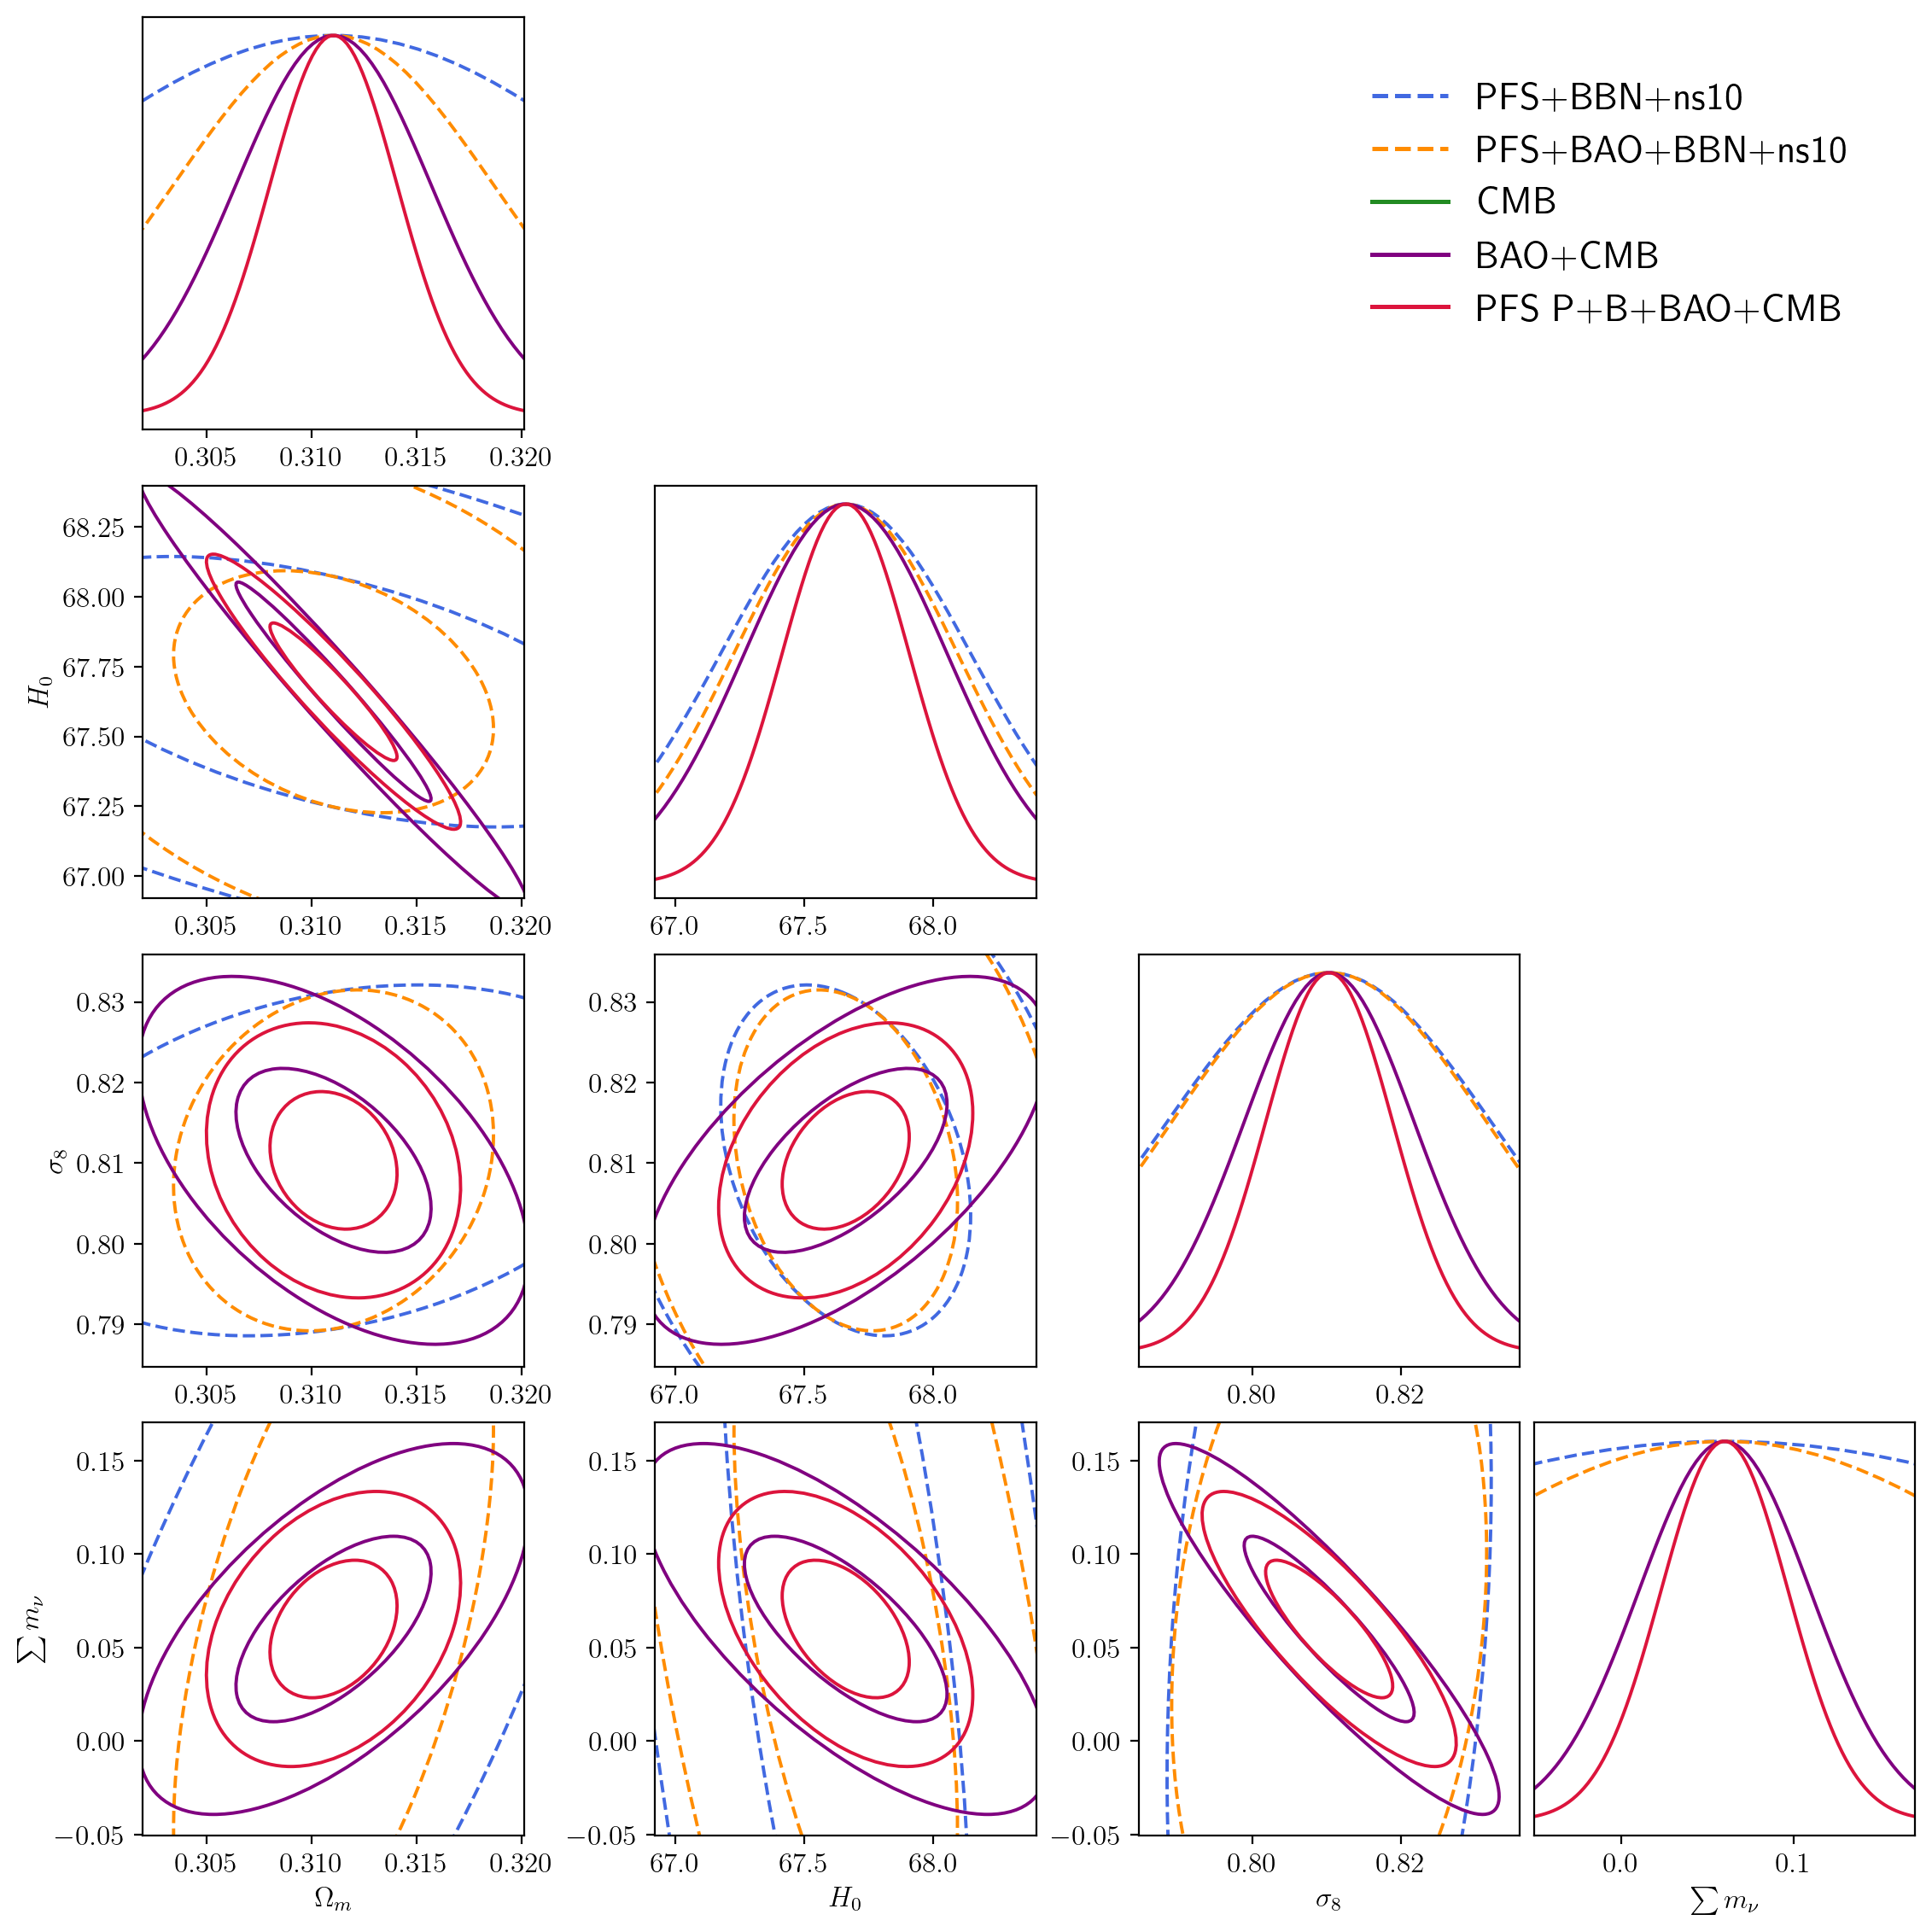

In [13]:
# ── Projected corner plot: Omega_m, H0, sigma8 (+ mnu when varied) ──
# Per-case colors/styles matching the shared-basis corner (next cell) and
# the reference fisher_multibin_*_AP_PB notebooks, in `cases` order.
proj_colors = ['royalblue', 'darkorange', 'forestgreen', 'purple', 'crimson']
proj_styles = ['--', '--', '-', '-', '-']

plt.rcParams.update({"font.size": 12})
n_proj = len(selected_param_labels)
fig = plt.figure(figsize=(n_proj * 2.8, n_proj * 2.8), constrained_layout=True)

proj_handles = [
    mlines.Line2D([], [], color=proj_colors[ci % len(proj_colors)],
                  ls=proj_styles[ci % len(proj_styles)], lw=1.8, label=case['label'])
    for ci, case in enumerate(selected_fisher_cases)
]

for i in range(n_proj):
    for j in range(n_proj):
        ax = plt.subplot(n_proj, n_proj, i * n_proj + j + 1)
        if j < i:
            for ci, case in enumerate(selected_fisher_cases):
                F = np.asarray(case['projection'].fisher_plot)
                sub = F[np.ix_([j, i], [j, i])]
                if np.linalg.matrix_rank(sub, tol=1e-10) < 2:
                    continue
                try:
                    plot_contours(
                        F, case['projection'].fid_plot, np.array([j, i]),
                        ax=ax, fill=False, color=proj_colors[ci % len(proj_colors)],
                        ls=proj_styles[ci % len(proj_styles)], lw=1.4,
                    )
                except Exception:
                    pass
        elif j == i:
            for ci, case in enumerate(selected_fisher_cases):
                F = np.asarray(case['projection'].fisher_plot)
                if F[i, i] < 1e-10:
                    continue
                try:
                    plot_Gaussian(F, case['projection'].fid_plot, i, ax=ax,
                                  color=proj_colors[ci % len(proj_colors)],
                                  ls=proj_styles[ci % len(proj_styles)], lw=1.4)
                except Exception:
                    pass
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == n_proj - 1:
            ax.set_xlabel(selected_param_labels[j])
        if j == 0 and i > 0:
            ax.set_ylabel(selected_param_labels[i])

fig.legend(handles=proj_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98),
           fontsize=16, frameon=False)

/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/604601941.py:40: RuntimeWarning: Fisher matrix is singular or ill-conditioned; plotting uses a pseudo-inverse fallback.
  plot_Gaussian(F, FIDUCIAL_SHARED, i, ax=ax, color=color, ls=ls, lw=1.4)
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/604601941.py:27: RuntimeWarning: Fisher matrix is singular or ill-conditioned; plotting uses a pseudo-inverse fallback.
  plot_contours(
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/604601941.py:27: RuntimeWarning: Skipping contour for indices [0, 1] because the marginal covariance is not positive semidefinite.
  plot_contours(
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_33083/604601941.py:40: RuntimeWarning: Skipping Gaussian marginal for index 1 because the variance is not finite and non-negative.
  plot_Gaussian(F, FIDUCIAL_SHARED, i, ax=ax, color=color, ls=ls, lw=1.4)
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_330

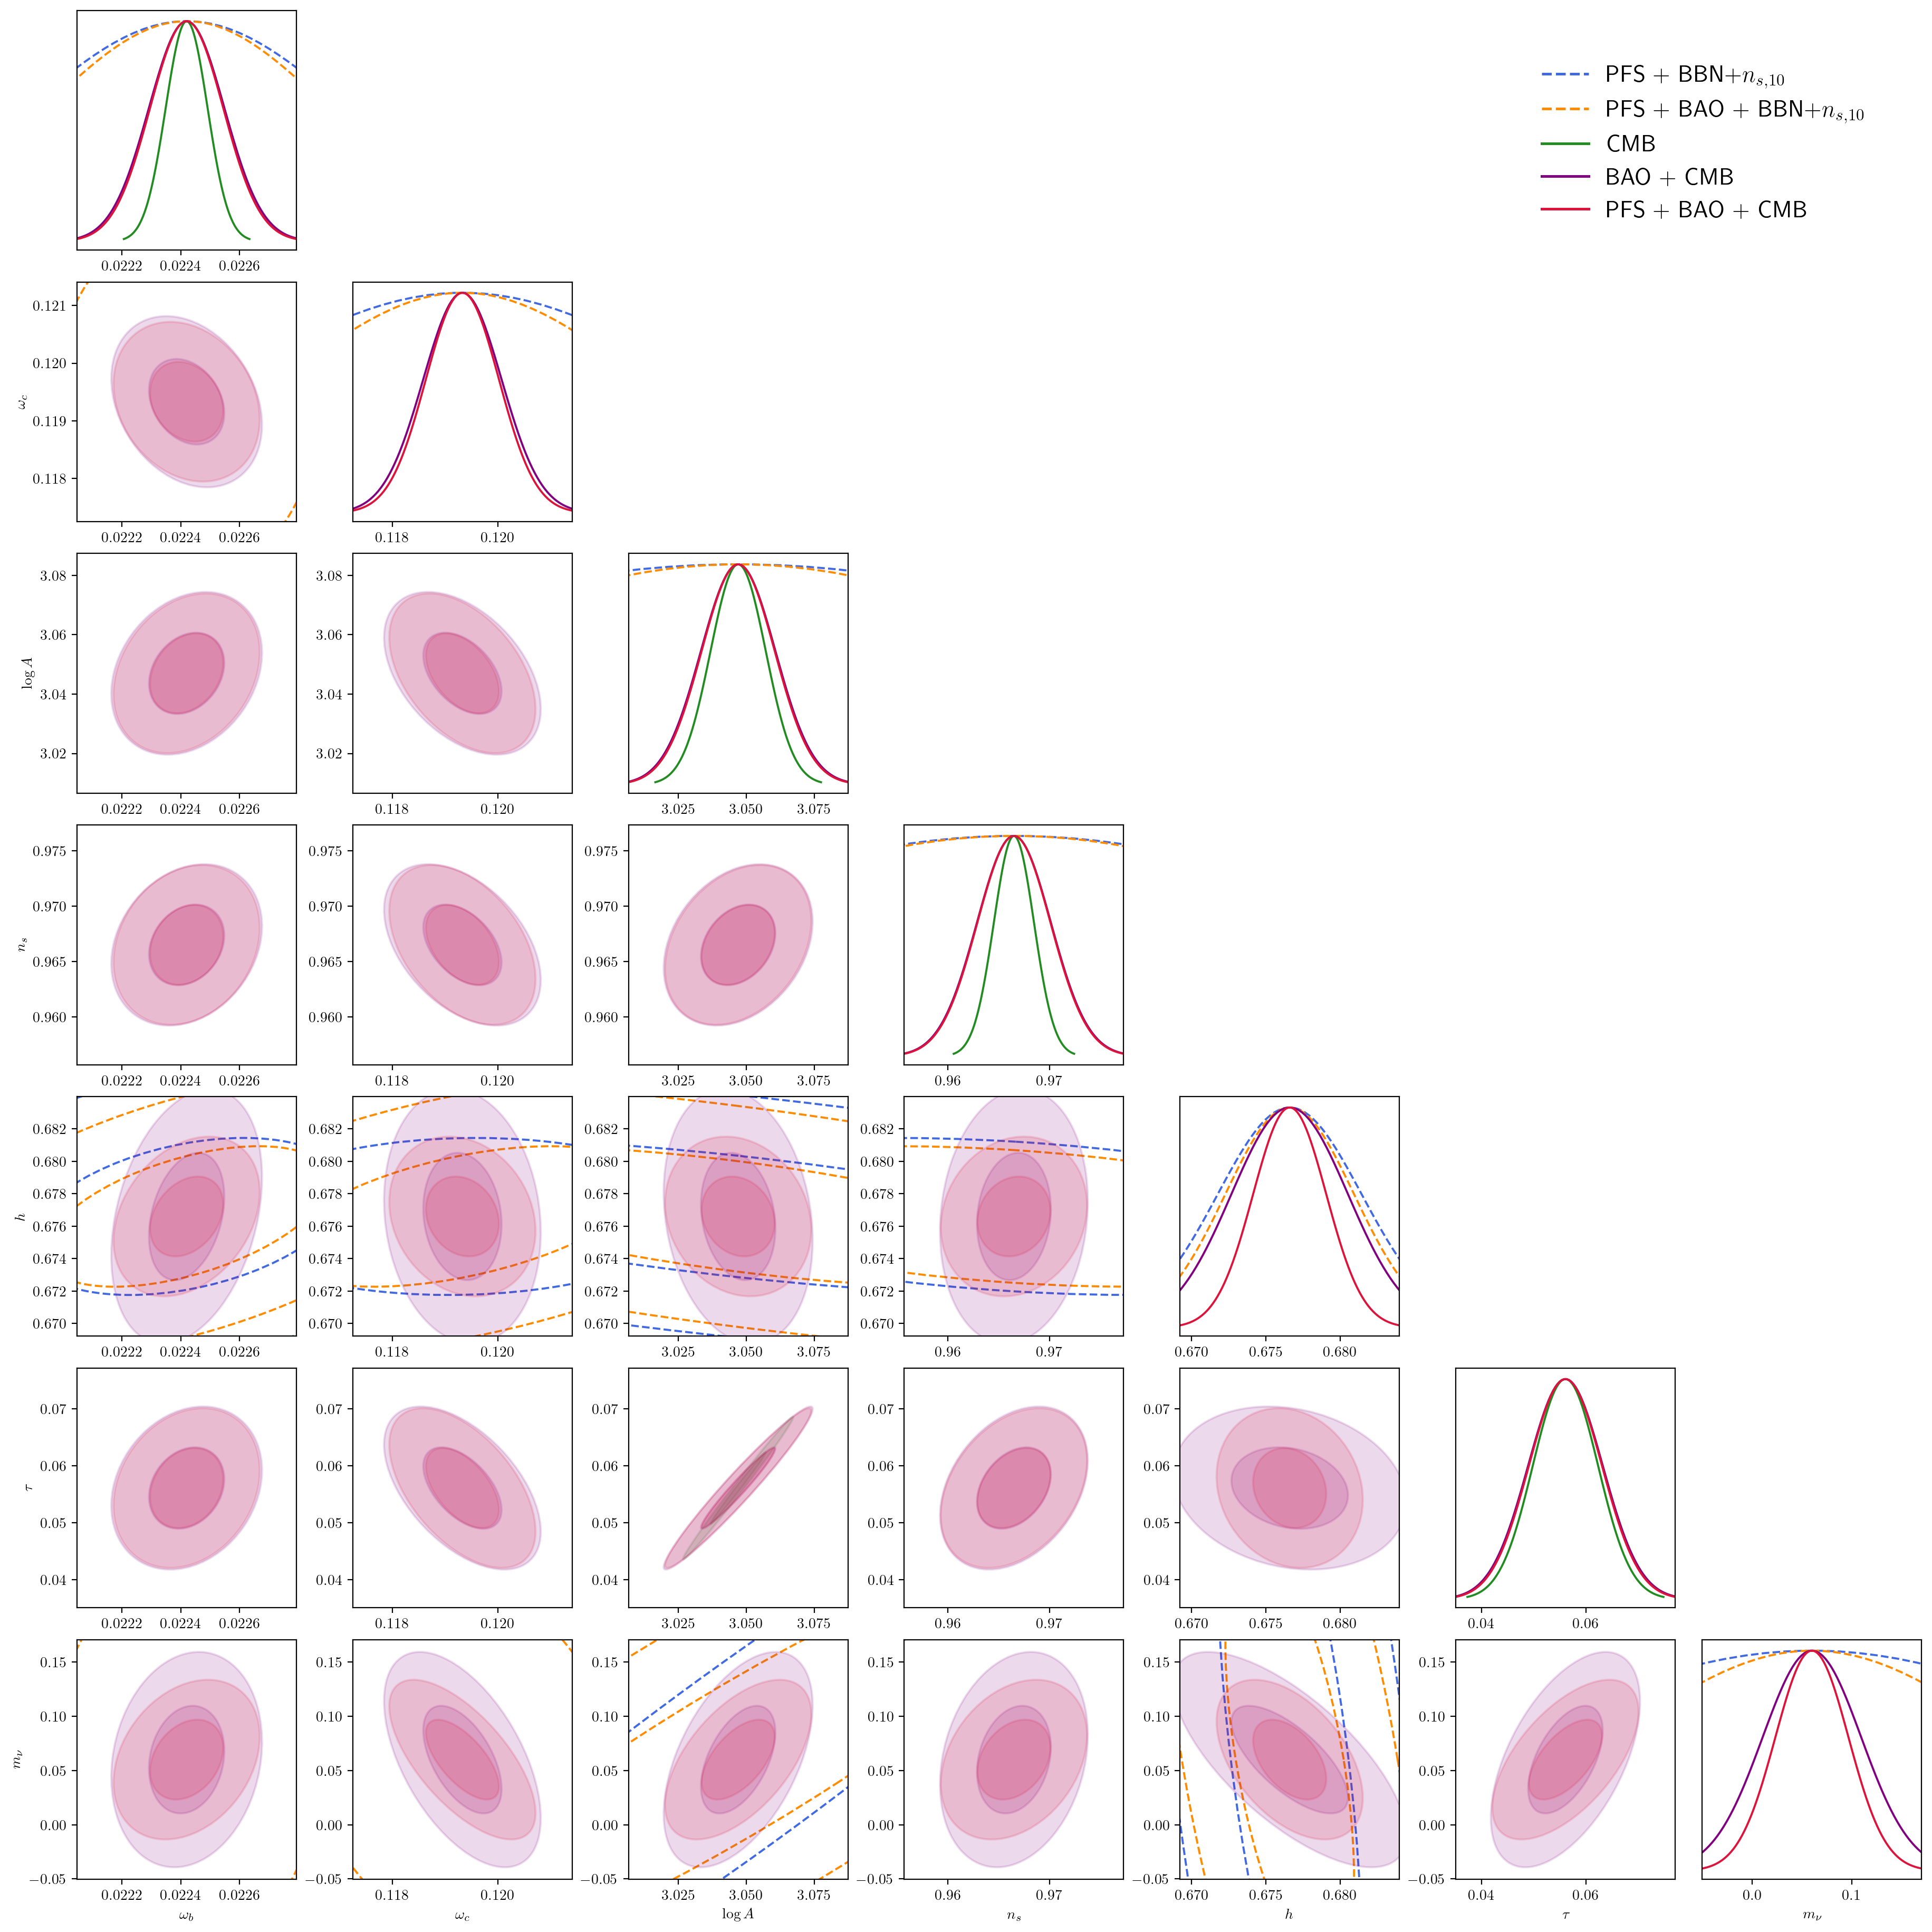

In [14]:
plot_cases = [
    (r'PFS + BBN+$n_{s,10}$',       F_pfs_prior_shared,     'royalblue',  '--', False),
    (r'PFS + BAO + BBN+$n_{s,10}$', F_pfs_bao_prior_shared, 'darkorange', '--', False),
    (r'CMB',             F_cmb_shared,     'forestgreen', '-',  True),
    (r'BAO + CMB',       F_bao_cmb_shared, 'purple',      '-',  True),
    (r'PFS + BAO + CMB', F_joint,          'crimson',     '-',  True),
]

plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_SHARED * 2.6, N_SHARED * 2.6), constrained_layout=True)

legend_handles = [
    mlines.Line2D([], [], color=c, ls=ls, lw=1.8, label=lbl)
    for lbl, _, c, ls, _ in plot_cases
]

for i in range(N_SHARED):
    for j in range(N_SHARED):
        ax = plt.subplot(N_SHARED, N_SHARED, i * N_SHARED + j + 1)

        if j < i:
            for label, F, color, ls, filled in plot_cases:
                sub = F[np.ix_([j, i], [j, i])]
                if np.linalg.matrix_rank(sub, tol=1e-10) < 2:
                    continue
                try:
                    plot_contours(
                        F, FIDUCIAL_SHARED, np.array([j, i]),
                        ax=ax, fill=filled, color=color, ls=ls, lw=1.4,
                        alpha=0.15 if filled else 1.0,
                    )
                except Exception:
                    pass

        elif j == i:
            for label, F, color, ls, filled in plot_cases:
                if F[i, i] < 1e-10:
                    continue
                try:
                    plot_Gaussian(F, FIDUCIAL_SHARED, i, ax=ax, color=color, ls=ls, lw=1.4)
                except Exception:
                    pass
            ax.set_yticks([])

        else:
            ax.axis('off')

        if i == N_SHARED - 1:
            ax.set_xlabel(SHARED_LABELS[j])
        if j == 0 and i > 0:
            ax.set_ylabel(SHARED_LABELS[i])

fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98),
           fontsize=16, frameon=False)

## Fisher diagnostics

In [15]:
print("PFS+BAO+BBN+ns10 Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_pfs_bao_prior_shared, param_names=list(SHARED_KEYS))))

print("PFS+BAO+CMB joint Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_joint, param_names=list(SHARED_KEYS))))
print()
print("BAO+CMB Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_bao_cmb_shared, param_names=list(SHARED_KEYS))))
print()
print("CMB-only Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_cmb_shared, param_names=list(SHARED_KEYS))))

PFS+BAO+BBN+ns10 Fisher diagnostics:
rank=6/7, weak_modes=1, cond=inf, sym_err=0.000e+00, weak_tol=9.293e-04
smallest eigenvalues: 0.000e+00, 1.849e+01, 5.155e+02
null-space participation: tau (1.00)
mode 0 [weak] eig=0.000e+00: tau (-1.000), mnu (+0.000), h (+0.000), ns (+0.000)
mode 1 [smallest] eig=1.849e+01: mnu (-0.846), logA (-0.523), ns (-0.100), h (+0.011)
mode 2 [smallest] eig=5.155e+02: logA (+0.785), mnu (-0.524), ns (+0.327), omch2 (-0.035)
PFS+BAO+CMB joint Fisher diagnostics:
rank=7/7, weak_modes=0, cond=2.736e+05, sym_err=0.000e+00, weak_tol=1.898e-02
smallest eigenvalues: 6.938e+02, 6.989e+03, 8.174e+04
null-space participation: mnu (0.93), logA (0.05)
mode 0 [smallest] eig=6.938e+02: mnu (-0.966), logA (-0.225), tau (-0.122), ns (-0.030)
mode 1 [smallest] eig=6.989e+03: logA (+0.867), tau (+0.424), mnu (-0.256), ns (+0.046)
mode 2 [smallest] eig=8.174e+04: ns (+0.944), h (+0.297), logA (-0.102), tau (+0.074)

BAO+CMB Fisher diagnostics:
rank=7/7, weak_modes=0, cond=4.7